# Convolutional Conditional Variational Autoencoder for MNIST

The MNIST VAE architecture is retained, with one-hot digit labels supplied to both the encoder and decoder.

## Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

CVAE_DIR = Path.cwd()
if not (CVAE_DIR / 'helper_train_cvae.py').exists():
    CVAE_DIR = Path.cwd() / 'autoencoders-generative-models' / 'cvae'
VAE_DIR = CVAE_DIR.parent / 'vae'
sys.path.insert(0, str(CVAE_DIR.resolve()))
sys.path.insert(0, str(VAE_DIR.resolve()))

from helper_data import get_dataloaders_mnist
from helper_plotting import plot_training_loss
from helper_utils import set_all_seeds
from helper_train_cvae import train_cvae_v1

## Settings

In [2]:
CUDA_DEVICE_NUM = 0
DEVICE = torch.device(
    f'cuda:{CUDA_DEVICE_NUM}' if torch.cuda.is_available() else 'cpu'
)
print('Device:', DEVICE)

RANDOM_SEED = 123
LEARNING_RATE = 0.0005
BATCH_SIZE = 256
NUM_EPOCHS = 50
NUM_CLASSES = 10
LATENT_SIZE = 2

Device: cuda:0


## Dataset

In [3]:
train_loader, valid_loader, test_loader = get_dataloaders_mnist(
    batch_size=BATCH_SIZE,
    num_workers=2,
    validation_fraction=0.0,
)

images, labels = next(iter(train_loader))
print('Image batch dimensions:', images.shape)
print('Label batch dimensions:', labels.shape)
print('First labels:', labels[:10])

Image batch dimensions: torch.Size([256, 1, 28, 28])
Label batch dimensions: torch.Size([256])
First labels: tensor([1, 4, 8, 2, 3, 2, 8, 5, 8, 6])


## Model

In [4]:
class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return x.view(self.shape)


class Trim(nn.Module):
    def forward(self, x):
        return x[:, :, :28, :28]


class CVAE(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, latent_size=LATENT_SIZE):
        super().__init__()
        self.num_classes = num_classes
        self.latent_size = latent_size

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, stride=1, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(32, 64, stride=2, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, stride=2, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.Conv2d(64, 64, stride=1, kernel_size=3, padding=1),
            nn.Flatten(),
        )

        conditioned_feature_size = 3136 + num_classes
        self.z_mean = nn.Linear(conditioned_feature_size, latent_size)
        self.z_log_var = nn.Linear(conditioned_feature_size, latent_size)

        self.decoder = nn.Sequential(
            nn.Linear(latent_size + num_classes, 3136),
            Reshape(-1, 64, 7, 7),
            nn.ConvTranspose2d(64, 64, stride=1, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 64, stride=2, kernel_size=3, padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(64, 32, stride=2, kernel_size=3, padding=0),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 1, stride=1, kernel_size=3, padding=0),
            Trim(),
            nn.Sigmoid(),
        )

    def one_hot(self, labels):
        return F.one_hot(labels, num_classes=self.num_classes).float()

    def encode(self, x, labels):
        features = self.encoder(x)
        conditioned_features = torch.cat((features, self.one_hot(labels)), dim=1)
        z_mean = self.z_mean(conditioned_features)
        z_log_var = self.z_log_var(conditioned_features)
        return z_mean, z_log_var

    def encoding_fn(self, x, labels):
        z_mean, z_log_var = self.encode(x, labels)
        return self.reparameterize(z_mean, z_log_var)

    def reparameterize(self, z_mean, z_log_var):
        eps = torch.randn_like(z_mean)
        return z_mean + eps * torch.exp(z_log_var / 2.0)

    def decode(self, z, labels):
        conditioned_z = torch.cat((z, self.one_hot(labels)), dim=1)
        return self.decoder(conditioned_z)

    def forward(self, x, labels):
        z_mean, z_log_var = self.encode(x, labels)
        encoded = self.reparameterize(z_mean, z_log_var)
        decoded = self.decode(encoded, labels)
        return encoded, z_mean, z_log_var, decoded

In [5]:
set_all_seeds(RANDOM_SEED)
model = CVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

CVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Flatten(start_dim=1, end_dim=-1)
  )
  (z_mean): Linear(in_features=3146, out_features=2, bias=True)
  (z_log_var): Linear(in_features=3146, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=3136, bias=True)
    (1): Reshape()
    (2): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): ConvTransp

## Training

In [6]:
log_dict = train_cvae_v1(
    num_epochs=NUM_EPOCHS,
    model=model,
    optimizer=optimizer,
    device=DEVICE,
    train_loader=train_loader,
    logging_interval=50,
    save_model='cvae_mnist_sigmoid_mse.pt',
)

Epoch: 001/050 | Batch 0000/0234 | Loss: 230.7250
Epoch: 001/050 | Batch 0050/0234 | Loss: 54.4744
Epoch: 001/050 | Batch 0100/0234 | Loss: 48.4031
Epoch: 001/050 | Batch 0150/0234 | Loss: 44.2639
Epoch: 001/050 | Batch 0200/0234 | Loss: 45.1631
Time elapsed: 0.03 min
Epoch: 002/050 | Batch 0000/0234 | Loss: 37.9637
Epoch: 002/050 | Batch 0050/0234 | Loss: 35.5782
Epoch: 002/050 | Batch 0100/0234 | Loss: 34.5198
Epoch: 002/050 | Batch 0150/0234 | Loss: 32.7968
Epoch: 002/050 | Batch 0200/0234 | Loss: 34.1899
Time elapsed: 0.05 min
Epoch: 003/050 | Batch 0000/0234 | Loss: 32.8855
Epoch: 003/050 | Batch 0050/0234 | Loss: 32.4406
Epoch: 003/050 | Batch 0100/0234 | Loss: 32.5198
Epoch: 003/050 | Batch 0150/0234 | Loss: 33.9573
Epoch: 003/050 | Batch 0200/0234 | Loss: 33.7530
Time elapsed: 0.07 min
Epoch: 004/050 | Batch 0000/0234 | Loss: 32.6573
Epoch: 004/050 | Batch 0050/0234 | Loss: 33.0468
Epoch: 004/050 | Batch 0100/0234 | Loss: 33.1925
Epoch: 004/050 | Batch 0150/0234 | Loss: 31.9239

## Evaluation

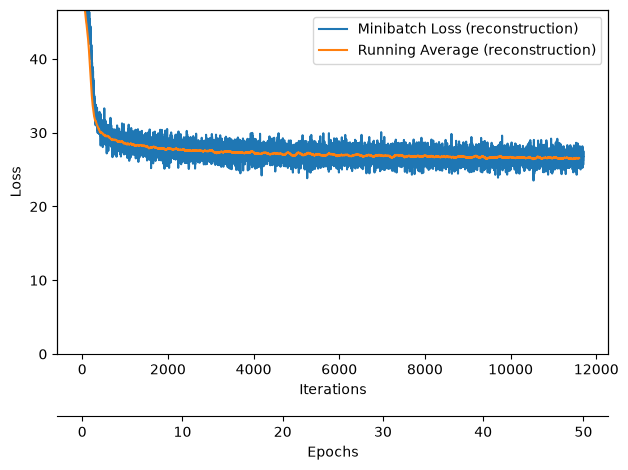

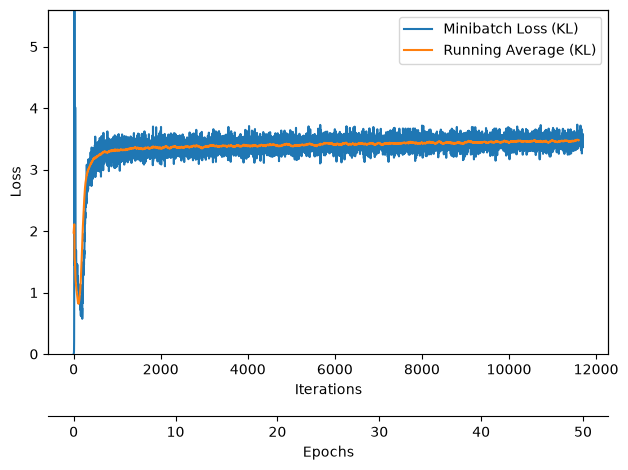

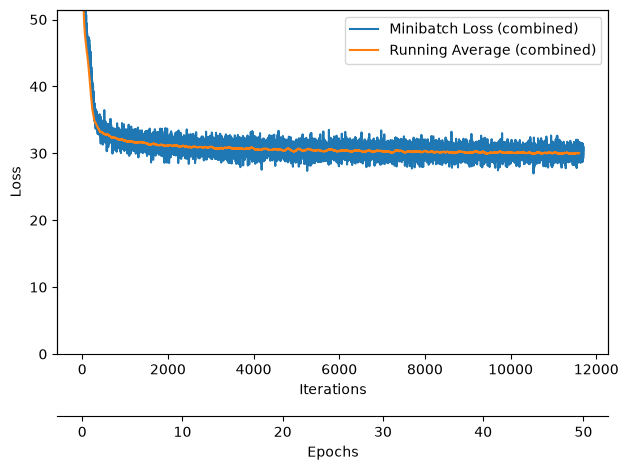

In [7]:
plot_training_loss(
    log_dict['train_reconstruction_loss_per_batch'],
    NUM_EPOCHS,
    custom_label=' (reconstruction)',
)
plot_training_loss(
    log_dict['train_kl_loss_per_batch'],
    NUM_EPOCHS,
    custom_label=' (KL)',
)
plot_training_loss(
    log_dict['train_combined_loss_per_batch'],
    NUM_EPOCHS,
    custom_label=' (combined)',
)
plt.show()

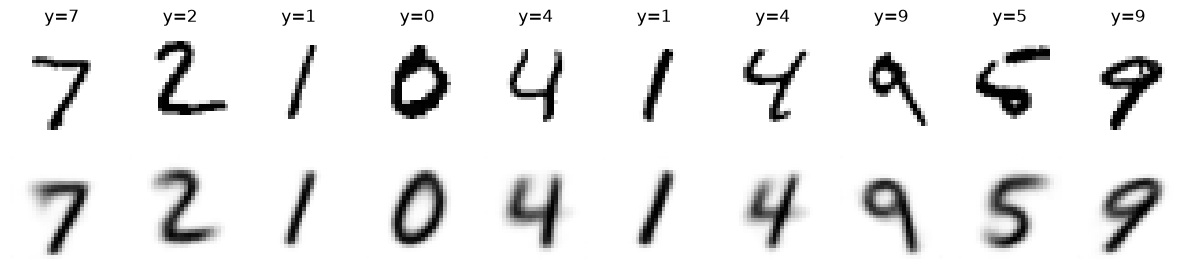

In [8]:
model.eval()
images, labels = next(iter(test_loader))
images = images[:10].to(DEVICE)
labels = labels[:10].to(DEVICE)

with torch.no_grad():
    _, _, _, reconstructions = model(images, labels)

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].imshow(images[i, 0].cpu(), cmap='binary')
    axes[0, i].set_title(f'y={labels[i].item()}')
    axes[1, i].imshow(reconstructions[i, 0].cpu(), cmap='binary')
    axes[0, i].axis('off')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

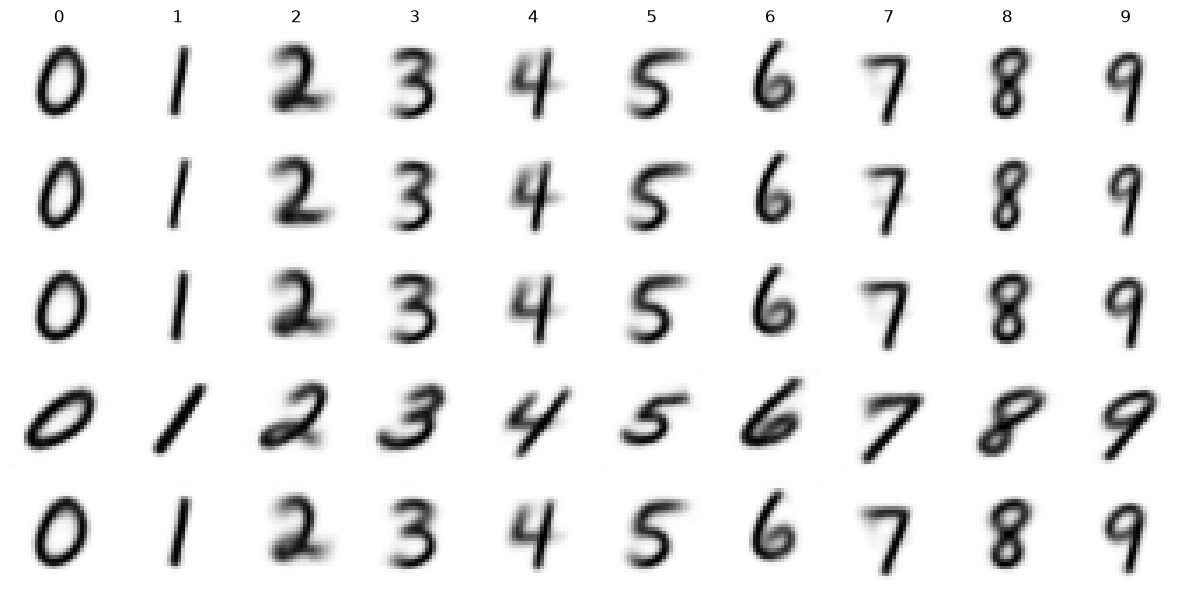

In [9]:
model.eval()
labels = torch.arange(NUM_CLASSES, device=DEVICE)

fig, axes = plt.subplots(5, NUM_CLASSES, figsize=(12, 6))
with torch.no_grad():
    for row in range(5):
        z = torch.randn(1, LATENT_SIZE, device=DEVICE).repeat(NUM_CLASSES, 1)
        generated = model.decode(z, labels)
        for digit in range(NUM_CLASSES):
            axes[row, digit].imshow(generated[digit, 0].cpu(), cmap='binary')
            axes[row, digit].axis('off')
            if row == 0:
                axes[row, digit].set_title(str(digit))
plt.tight_layout()
plt.show()

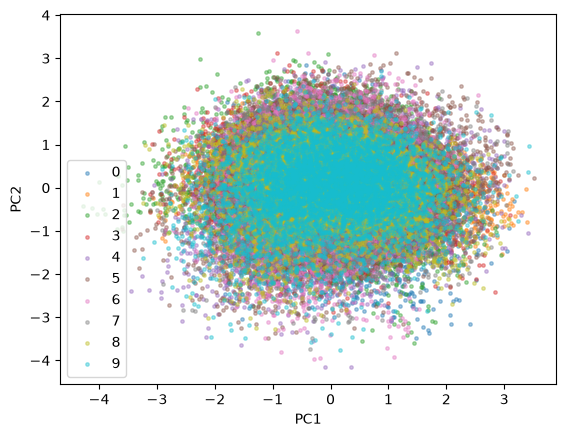

In [10]:
model.eval()
latent_means = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        z_mean, _ = model.encode(images, labels)
        latent_means.append(z_mean.cpu())
        all_labels.append(labels.cpu())

latent_means = torch.cat(latent_means)
all_labels = torch.cat(all_labels)
centered = latent_means - latent_means.mean(dim=0, keepdim=True)
_, _, principal_directions = torch.pca_lowrank(centered, q=2)
latent_2d = centered @ principal_directions[:, :2]

for digit in range(NUM_CLASSES):
    digit_points = latent_2d[all_labels == digit]
    plt.scatter(
        digit_points[:, 0], digit_points[:, 1], s=6, alpha=0.4, label=str(digit)
    )
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()